In [1]:
from sklearn.preprocessing import StandardScaler
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.axes as maxes
import scipy
from scipy.stats import pearsonr
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpecFromSubplotSpec
from scipy import linalg

plot_path = '/home/u/u241308/figures/'

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
#anomaly reference period
ref_min = 1985
ref_max = 2014

In [3]:
#correlation time period
time_min = 1960
time_max = 2020

In [4]:
#select North Atlantic area
lon_min_na = -70
lon_max_na = 20#30
lat_min_na = 30#20
lat_max_na = 80

In [5]:
#select SPG area
lon_min_spg = -60
lon_max_spg = -10
lat_min_spg = 50
lat_max_spg = 66

# Z500

In [6]:
lead_year = 1 #2

In [7]:
if lead_year == 1:
    lead_min = 1 # 2 to start in January, first lead year
    lead_max = 13 # 14 To end in December, first lead year
if lead_year == 2:
    lead_min = 13 # 14 to start in January, second lead year
    lead_max = 25 # 26 to end in December, second lead year

In [8]:
#Hybrid-ML
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/z500_ML_NA/anomaly/'
    file = 'z500_%i_r1-16i2p3-LR_26_months_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as z500_ML:
        z500_ML = z500_ML.zg.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(z500_ML)

#concatenate along time dimension
z500_ML = xr.concat(sliced_datasets,dim='time')

#new longitudes
z500_ML['lon'] = np.where(z500_ML.lon > 180,z500_ML.lon-360,z500_ML.lon)
ind_sort = np.argsort(z500_ML.lon)
z500_ML = z500_ML[:,:,:,ind_sort.values]
#select lon/lat
lon_sel = (z500_ML.lon >= lon_min_na) & (z500_ML.lon <= lon_max_na)
lat_sel = (z500_ML.lat >= lat_min_na) & (z500_ML.lat <= lat_max_na)

z500_ML = z500_ML[:,:,lat_sel,lon_sel]

#change 'depth' dimension name to 'sfc', so the dimension name matches with TAS (only for ML, not for MPI)
z500_ML = z500_ML.rename({"plev_2": "sfc"})
#give different coordinates for each ensemble member in sfc:
z500_ML = z500_ML.assign_coords(sfc=np.arange(1, 17))

#homogenize time dimension, so each month's time corresponds to the first day, and first our
z500_ML['time'] = pd.to_datetime(z500_ML['time']) - pd.offsets.MonthBegin()
z500_ML['time'] = z500_ML['time'].dt.floor('D')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [9]:
#Standard
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/z500_benchmark/anomaly/'
    file = 'z500_%i_r1-16i2p2-LR_3_years_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as z500_MPI:
        z500_MPI = z500_MPI.zg.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(z500_MPI)

#concatenate along time dimension
z500_MPI = xr.concat(sliced_datasets,dim='time')

#new longitudes
z500_MPI['lon'] = np.where(z500_MPI.lon > 180,z500_MPI.lon-360,z500_MPI.lon)
ind_sort = np.argsort(z500_MPI.lon)
z500_MPI = z500_MPI[:,:,:,ind_sort.values]
#select lon/lat
lon_sel = (z500_MPI.lon >= lon_min_na) & (z500_MPI.lon <= lon_max_na)
lat_sel = (z500_MPI.lat >= lat_min_na) & (z500_MPI.lat <= lat_max_na)

z500_MPI = z500_MPI[:,:,lat_sel,lon_sel]

#change 'depth' dimension name to 'sfc', so the dimension name matches with TAS (only for ML, not for MPI)
z500_MPI = z500_MPI.rename({"plev_2": "sfc"})
#give different coordinates for each ensemble member in sfc:
z500_MPI = z500_MPI.assign_coords(sfc=np.arange(1, 17))

#homogenize time dimension, so each month's time corresponds to the first day, and first our
z500_MPI['time'] = z500_MPI['time'].dt.floor('D')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [10]:
#ERA
path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/era5/'
file = 'era5_z500_1940-2023_360x180_anomaly_ref_%i-%i.nc' %(ref_min,ref_max)
z500_era = xr.open_dataset(path+file).z

#select period
z500_era = z500_era[(z500_era.time.dt.year>=time_min)&(z500_era.time.dt.year<=time_max)]

#new longitudes
z500_era['lon'] = np.where(z500_era.lon > 180,z500_era.lon-360,z500_era.lon)
ind_sort = np.argsort(z500_era.lon)
z500_era = z500_era[:,:,ind_sort.values]


lon_sel = (z500_era.lon >= lon_min_na) & (z500_era.lon <= lon_max_na)
lat_sel = (z500_era.lat >= lat_min_na) & (z500_era.lat <= lat_max_na)

z500_era = z500_era[:,lat_sel,lon_sel]

#homogenize to MPI and ML
z500_era = z500_era.sel(time=slice(z500_MPI.time[0].time, z500_MPI.time[-1].time))

# Compute seasonal mean

In [11]:
#save lon/lat dimensions
lat_z500 = z500_era.lat.shape[0]
lon_z500 = z500_era.lon.shape[0]

In [12]:
def compute_seasonal_means(da):
    time = da['time'].to_index()

    season_year = time.year + (time.month == 12)
    season = da['time'].dt.season.values

    season_id = [f"{y}-{s}" for y, s in zip(season_year, season)]

    da = da.assign_coords(
        season=('time', season),
        season_year=('time', season_year),
        season_id=('time', season_id)
    )

    grouped = da.groupby('season_id').mean('time')

    season_ts = {}
    for sid in grouped['season_id'].values:
        year, s = sid.split('-')
        year = int(year)
        if s not in season_ts:
            season_ts[s] = []
        da_season = grouped.sel(season_id=sid).expand_dims({'season_year': [year]})
        season_ts[s].append(da_season)

    for season in season_ts:
        season_ts[season] = xr.concat(season_ts[season], dim='season_year')

    return season_ts

In [13]:
# Compute seasonal mean
z500_era_seasonal = compute_seasonal_means(z500_era)

z500_MPI_seasonal = compute_seasonal_means(z500_MPI)

z500_ML_seasonal = compute_seasonal_means(z500_ML)

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/sw/spa

# Compute EOF

In [14]:
def compute_eof(z500,mode):
    lat_rad = np.deg2rad(z500.lat)
    weights = np.sqrt(np.cos(lat_rad))   # dims: (lat,)

    z500_weighted = z500 * weights
    
    nlat = z500_weighted.sizes['lat']
    nlon = z500_weighted.sizes['lon']
    
    z500_2d = z500_weighted.values.reshape(-1, nlat * nlon)
    
    valid_mask = ~np.any(np.isnan(z500_2d), axis=0)
    z500_2d_valid = z500_2d[:, valid_mask]
    
    z500_2d_anom = z500_2d_valid - np.mean(z500_2d_valid, axis=0)
    
    U, S, VT = linalg.svd(z500_2d_anom, full_matrices=False)
    EOFs = VT  # shape: (n_modes, n_valid_gridpoints)
    PCs = U * S  # shape: (time, n_modes)
    
    var_frac = (S**2) / np.sum(S**2)
    
    EOF1_full = np.full(nlat * nlon, np.nan)
    EOF1_full[valid_mask] = EOFs[mode]
    EOF1_map = EOF1_full.reshape(nlat, nlon)
    
    PCs = PCs[:,mode]
    var_frac = var_frac[0]
    
    return(EOF1_map,PCs,var_frac)

In [15]:
period_min = 1960
period_max = 1991
window = 30

seas_sel = 'DJF'
mode=0

r_nao_MPI_ly1_list = [] 
p_nao_MPI_ly1_list = []
r_nao_ML_ly1_list = [] 
p_nao_ML_ly1_list = []
eof_era_list = []
eof_MPI_list = []
eof_ML_list = []

for y in range(period_min,period_max+1):
    w_start = y
    w_end = y+window

    #select season and years
    z500_MPI_sel = z500_MPI_seasonal[seas_sel].sel(season_year=slice(w_start,w_end))
    z500_ML_sel = z500_ML_seasonal[seas_sel].sel(season_year=slice(w_start,w_end))
    z500_era_sel = z500_era_seasonal[seas_sel].sel(season_year=slice(w_start,w_end))
    
    #stack years and ensemble members
    z500_MPI_seasonal_stack = z500_MPI_sel.stack(time_ens=('season_year', 'sfc')).transpose('time_ens', 'lat', 'lon')
    z500_ML_seasonal_stack = z500_ML_sel.stack(time_ens=('season_year', 'sfc')).transpose('time_ens', 'lat', 'lon')

    #compute EOF
    eof_era,pc_era,var_exp_era = compute_eof(z500_era_sel,mode)
    eof_MPI,pc_MPI,var_exp_MPI = compute_eof(z500_MPI_seasonal_stack,mode)
    eof_ML,pc_ML,var_exp_ML = compute_eof(z500_ML_seasonal_stack,mode)

    # std to standarize EOF output
    pc_era_std = np.std(pc_era)
    pc_MPI_std = np.std(pc_MPI)
    pc_ML_std = np.std(pc_ML)

    # Wrap PCs into a DataArray, using the original stacked coordinate, and unstack
    pc_MPI_da = xr.DataArray(
        pc_MPI,
        dims=['time_ens'],
        coords={'time_ens': z500_MPI_seasonal_stack['time_ens']}
    )
    pc_MPI_unstack = pc_MPI_da.unstack('time_ens') 
        
    pc_ML_da = xr.DataArray(
        pc_ML,
        dims=['time_ens'],
        coords={'time_ens': z500_ML_seasonal_stack['time_ens']}
    )
    pc_ML_unstack = pc_ML_da.unstack('time_ens') 

    #align signs
    if eof_era[-10,0] > 0:
        pc_era = pc_era * (-1)
        eof_era = eof_era * (-1)
    if eof_MPI[-10,0] > 0:
        pc_MPI_unstack = pc_MPI_unstack * (-1)
        eof_MPI = eof_MPI * (-1)
    if eof_ML[-10,0] > 0:
        pc_ML_unstack = pc_ML_unstack * (-1)
        eof_ML = eof_ML * (-1)

    #compute skill as correlation
    MPI_corr_sst = scipy.stats.pearsonr(pc_era/pc_era_std,pc_MPI_unstack.mean(dim='sfc')/pc_MPI_std)
    ML_corr_sst = scipy.stats.pearsonr(pc_era/pc_era_std,pc_ML_unstack.mean(dim='sfc')/pc_ML_std)

    #append
    r_nao_MPI_ly1_list.append(MPI_corr_sst[0]) 
    p_nao_MPI_ly1_list.append(MPI_corr_sst[1])
    r_nao_ML_ly1_list.append(ML_corr_sst[0]) 
    p_nao_ML_ly1_list.append(ML_corr_sst[1])

    eof_era_list.append(eof_era)
    eof_ML_list.append(eof_ML)
    eof_MPI_list.append(eof_MPI)

    print('Window starting on %i done' %w_start)

Window starting on 1960 done
Window starting on 1961 done
Window starting on 1962 done
Window starting on 1963 done
Window starting on 1964 done
Window starting on 1965 done
Window starting on 1966 done
Window starting on 1967 done
Window starting on 1968 done
Window starting on 1969 done
Window starting on 1970 done
Window starting on 1971 done
Window starting on 1972 done
Window starting on 1973 done
Window starting on 1974 done
Window starting on 1975 done
Window starting on 1976 done
Window starting on 1977 done
Window starting on 1978 done
Window starting on 1979 done
Window starting on 1980 done
Window starting on 1981 done
Window starting on 1982 done
Window starting on 1983 done
Window starting on 1984 done
Window starting on 1985 done
Window starting on 1986 done
Window starting on 1987 done
Window starting on 1988 done
Window starting on 1989 done
Window starting on 1990 done
Window starting on 1991 done


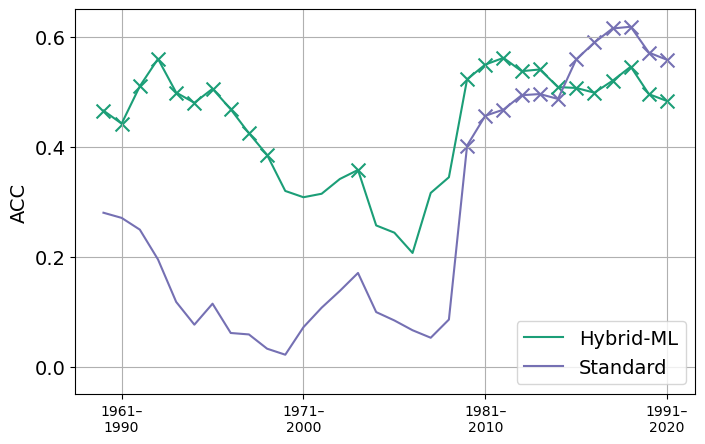

In [24]:
x_plot = np.arange(period_min,period_max+1)
ylim_min=-0.05
ylim_max=0.65

x_plot = np.arange(period_min+window-1,period_max+window)
# Labels showing the full period represented by each point
tick_years = np.array([1990, 2000, 2010, 2020])
x_labels = [
    f"{year - window + 1}\u2013\n{year}"
    for year in tick_years
]

fig = plt.figure(figsize=(8,5))
plt.rcParams.update({'font.size': 14})
ax1= fig.add_subplot(1,1,1)
plt.plot(x_plot,r_nao_ML_ly1_list,'#1b9e77',label='Hybrid-ML')
plt.plot(x_plot,r_nao_MPI_ly1_list,'#7570b3',label='Standard')
# add X on significant skill
sig_ML = np.array(p_nao_ML_ly1_list) < 0.05
sig_MPI = np.array(p_nao_MPI_ly1_list) < 0.05
ax1.scatter(x_plot[sig_MPI],
            np.array(r_nao_MPI_ly1_list)[sig_MPI],
            marker='x', color='#7570b3', s=100, label='_nolegend_')

ax1.scatter(x_plot[sig_ML],
            np.array(r_nao_ML_ly1_list)[sig_ML],
            marker='x', color='#1b9e77', s=100, label='_nolegend_')
plt.legend(loc='lower right')
plt.ylim([ylim_min,ylim_max])
plt.grid()

plt.ylabel('ACC')

ax1.set_xticks(tick_years)
ax1.set_xticklabels(x_labels, ha='center')
ax1.set_yticks([0, 0.2, 0.4, 0.6])

plt.savefig(plot_path+'nao_skill_%ileadyear_running_window_anomaly_ref_%i-%i'%(
            lead_year,ref_min,ref_max), bbox_inches="tight", dpi=100)